# **Pipeline 1 : Spatial Domain Enhancement Pipeline**

1.	Convert image to grayscale


2.	Apply Mean Filtering (Averaging Filter)


3.	Apply CLAHE (Contrast Limited Adaptive Histogram Equalization)


4.	Apply Adaptive Gamma Correction


5.	Sharpening using guassian
6.	Normalize final output


In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def xray_enhancement_pipeline(
    image_path,
    clahe_clip=2.0,
    clahe_grid=(8, 8),
    gamma=1.1,
    kernel_size=3,
    show=True
):
    # 1. Grayscale
    original = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    if original is None:
        raise ValueError("Invalid image path")

    img = original.astype(np.float32)

    # 2. Mean filtering
    img = cv2.blur(img, (kernel_size, kernel_size))

    # 3. CLAHE
    clahe = cv2.createCLAHE(clipLimit=clahe_clip, tileGridSize=clahe_grid)
    img = clahe.apply(img.astype(np.uint8)).astype(np.float32)

    # 4. Gamma correction
    img = (img / 255.0) ** gamma * 255.0

    # 5. sharpening
    blur = cv2.GaussianBlur(img, (3, 3), 0)
    img = img + 0.4 * (img - blur)

    # 6. Normalization
    img = cv2.normalize(img, None, 0, 255, cv2.NORM_MINMAX)
    img = img.astype(np.uint8)

    # Display
    if show:
        plt.figure(figsize=(10, 5))

        plt.subplot(1, 2, 1)
        plt.title("Original X-ray")
        plt.imshow(original, cmap="gray")
        plt.axis("off")

        plt.subplot(1, 2, 2)
        plt.title("Enhanced X-ray")
        plt.imshow(img, cmap="gray")
        plt.axis("off")

        plt.tight_layout()
        plt.show()

    return original, img

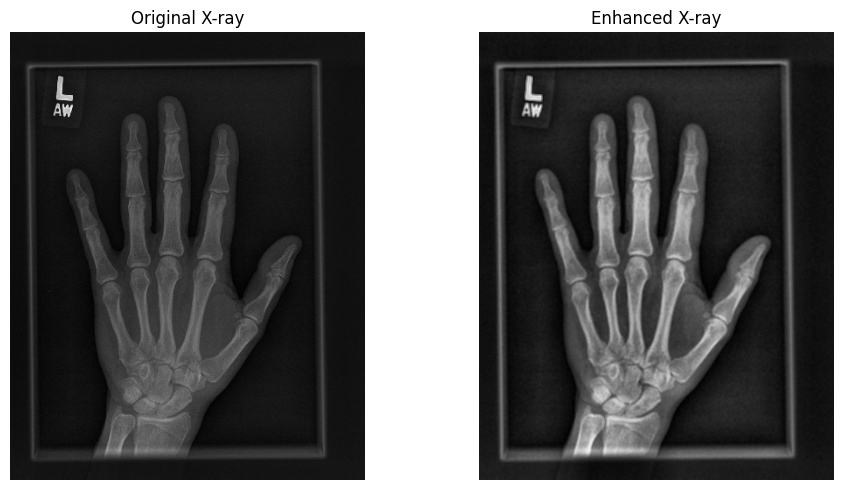

In [ ]:
original, enhanced = xray_enhancement_pipeline("/content/image3.png")

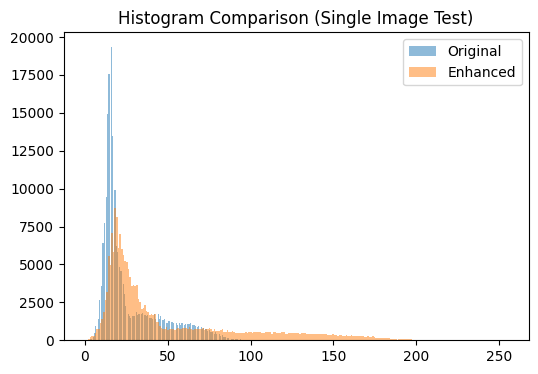

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))

plt.hist(original.ravel(), bins=256, alpha=0.5, label="Original")
plt.hist(enhanced.ravel(), bins=256, alpha=0.5, label="Enhanced")

plt.legend()
plt.title("Histogram Comparison (Single Image Test)")
plt.show()

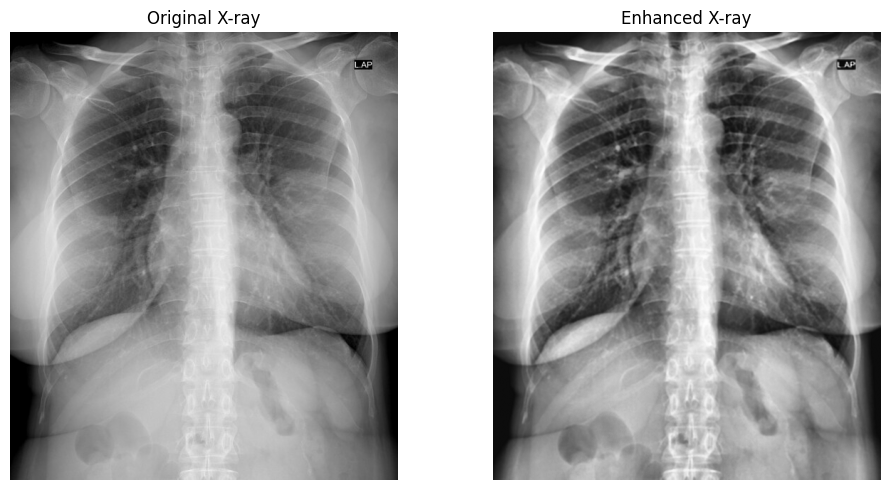

In [ ]:
original, enhanced = xray_enhancement_pipeline("/content/fractured rib.jpeg")

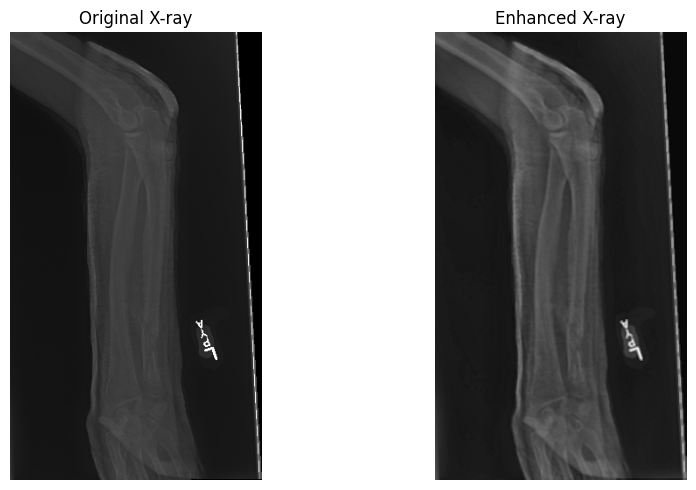

In [ ]:
original, enhanced = xray_enhancement_pipeline("/content/image2.png",)

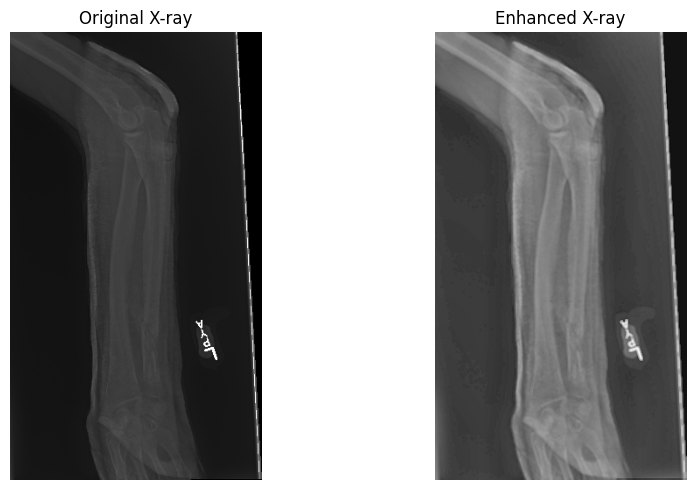

In [ ]:
original, enhanced = xray_enhancement_pipeline("/content/image2.png",gamma=0.6)

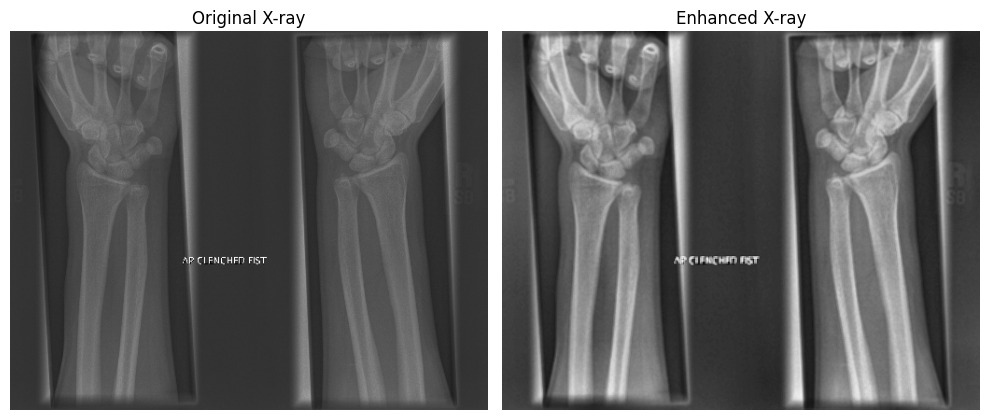

In [ ]:
original, enhanced = xray_enhancement_pipeline("/content/image2 (1).png")

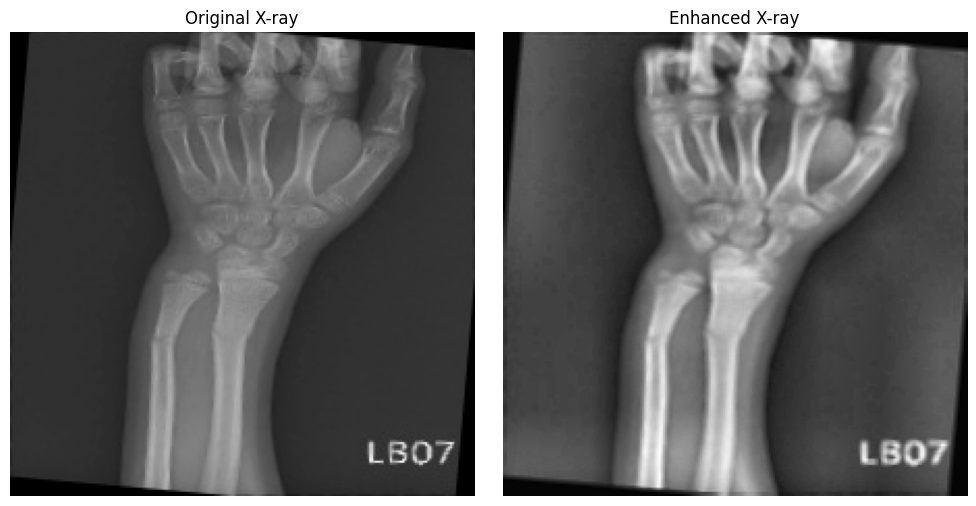

In [ ]:
original, enhanced = xray_enhancement_pipeline("/content/fractured arm.jpg",gamma=1)

# **Observations :**
1.	Excellent for Low Contrast Scans X-rays where tissues have similar intensities
2.	Great for visualizing fractures, joint spaces, and cortical bone details.
3.	Computationally cheap
4.	CLAHE significantly create "halos" or unrealistic shadows in case of intense noise
